
# Análisis de Churn de Clientes – PYMER

## Contexto del proyecto
Este notebook desarrolla un modelo de *Machine Learning* para predecir **Churn de clientes**
en una empresa fintech que brinda soluciones financieras a **PYMES argentinas**.

El objetivo es anticipar la baja de clientes para permitir acciones preventivas,
y posteriormente desplegar el modelo mediante una **API de predicción**.

El documento integra:
- 0. Carga del dataset
- 1. Exploración y limpieza de datos (EDA)
- 2. Estadísticas y gráficos
- 3. Ingeniería de features
- 4. Entrenamiento del modelo
- 5. Evaluación del modelo
- 6. Conclución
- 7. Extra (test)


# **0. Carga del dataset**

In [ ]:
data = "https://raw.githubusercontent.com/agusvillalobosok/ChurnInsight/002193db46934c03311d5b3486c15833c1874daf/Datos/dataset_fintech_xl.csv"

In [ ]:
import pandas as pd

df = pd.read_csv(data)
df.columns = df.columns.str.upper()



# **1. Exploración y Limpieza de los Datos (EDA)**

En esta sección se realiza una inspección inicial del dataset para comprender
su estructura, calidad y principales características.  
Se analizan tipos de variables, valores faltantes, duplicados y estadísticas descriptivas.


In [ ]:
# ============================================
# 1. Cargando las bibliotecas
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns





## Información general, valores nulos y duplicados.



In [ ]:
print("\nInformación general:")
print(df.info())




Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4272 entries, 0 to 4271
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   NOMBRE_EMPRESA               4272 non-null   object 
 1   CUIT                         4272 non-null   int64  
 2   PERIODO_FISCAL               4272 non-null   object 
 3   EMPLEADOS                    4272 non-null   int64  
 4   INGRESOS                     4272 non-null   float64
 5   GASTOS                       4272 non-null   float64
 6   MARGEN                       4272 non-null   float64
 7   DEUDA                        4272 non-null   float64
 8   ACTIVOS                      4272 non-null   float64
 9   PRESTAMOS_SOLICITADOS        4272 non-null   int64  
 10  PRESTAMOS_APROBADOS          4272 non-null   int64  
 11  MONTO_SOLICITADO             4272 non-null   float64
 12  MONTO_APROBADO               4272 non-null   float64
 

In [ ]:
# valores nulos

print("\nValores nulos por columna:")
print(df.isnull().sum())




Valores nulos por columna:
NOMBRE_EMPRESA                 0
CUIT                           0
PERIODO_FISCAL                 0
EMPLEADOS                      0
INGRESOS                       0
GASTOS                         0
MARGEN                         0
DEUDA                          0
ACTIVOS                        0
PRESTAMOS_SOLICITADOS          0
PRESTAMOS_APROBADOS            0
MONTO_SOLICITADO               0
MONTO_APROBADO                 0
TICKET_PROMEDIO_SOLICITADO     0
TICKET_PROMEDIO_APROBADO       0
PRESTAMOS_CANCELADOS           0
PRESTAMOS_VIGENTES             0
TIEMPO_CANCELACION_PRESTAMO    0
SERVICIOS_UTILIZADOS           0
TRANSFERENCIAS                 0
PAGOS                          0
CREDITOS                       0
INVERSIONES                    0
TRIMESTRE_DIAS_ACTIVIDAD       0
TRIMESTRE_DIAS_INACTIVIDAD     0
PROMEDIO_LOGIN_DIA             0
TOTAL_LOGIN_DIA                0
CHURN                          0
dtype: int64


In [ ]:
# Valores duplicados
print("\nDuplicados:", df.duplicated().sum())


Duplicados: 0


# **2. Estadísticas y gráficos**

In [ ]:
# Estadísticas básicas
print("\nEstadísticas descriptivas:")
display(df.describe())


Estadísticas descriptivas:


,CUIT,EMPLEADOS,INGRESOS,GASTOS,MARGEN,DEUDA,ACTIVOS,PRESTAMOS_SOLICITADOS,PRESTAMOS_APROBADOS,MONTO_SOLICITADO,...,SERVICIOS_UTILIZADOS,TRANSFERENCIAS,PAGOS,CREDITOS,INVERSIONES,TRIMESTRE_DIAS_ACTIVIDAD,TRIMESTRE_DIAS_INACTIVIDAD,PROMEDIO_LOGIN_DIA,TOTAL_LOGIN_DIA,CHURN
count,4.272000e+03,4272.000000,4.272000e+03,4.272000e+03,4.272000e+03,4.272000e+03,4.272000e+03,4272.000000,4272.000000,4.272000e+03,...,4272.000000,4272.000000,4272.000000,4272.000000,4272.000000,4272.000000,4272.000000,4272.000000,4272.000000,4272.000000
mean,4.000469e+10,166.090824,4.000452e+07,2.955764e+07,1.044689e+07,1.206876e+07,5.541846e+07,2.498596,1.073736,6.510103e+06,...,1.286985,0.492041,0.499298,0.448736,0.503511,50.685393,38.930946,3.892662,190.893001,0.511002
std,2.401588e+10,127.161398,2.382779e+07,1.878412e+07,8.063725e+06,1.001829e+07,3.657817e+07,1.704044,1.297817,1.049519e+07,...,1.078097,0.499995,0.500058,0.497423,0.500046,23.314215,23.387469,2.513462,159.362441,0.499937
min,1.424082e+08,5.000000,1.041582e+06,5.959996e+05,-6.235070e+06,0.000000e+00,1.122155e+06,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000,1.000000,0.000000
25%,2.343891e+10,72.000000,2.053364e+07,1.438219e+07,3.966620e+06,3.325819e+06,2.370587e+07,1.000000,0.000000,1.505770e+05,...,0.000000,0.000000,0.000000,0.000000,0.000000,31.000000,19.000000,2.000000,76.990000,0.000000
50%,3.095279e+10,134.000000,3.924843e+07,2.750099e+07,8.862702e+06,9.568110e+06,4.870939e+07,2.000000,1.000000,4.763536e+05,...,1.000000,0.000000,0.000000,0.000000,1.000000,51.000000,39.000000,3.405000,145.000000,1.000000
75%,5.545975e+10,218.000000,5.669068e+07,4.205816e+07,1.526472e+07,1.932568e+07,8.595737e+07,4.000000,2.000000,1.023634e+07,...,2.000000,1.000000,1.000000,1.000000,1.000000,71.000000,58.000000,5.000000,256.542500,1.000000
max,9.993606e+10,497.000000,1.273059e+08,1.076533e+08,5.437219e+07,5.081315e+07,1.664481e+08,5.000000,5.000000,5.420555e+07,...,4.000000,1.000000,1.000000,1.000000,1.000000,90.000000,89.000000,10.000000,900.000000,1.000000


## Distribución de Churn

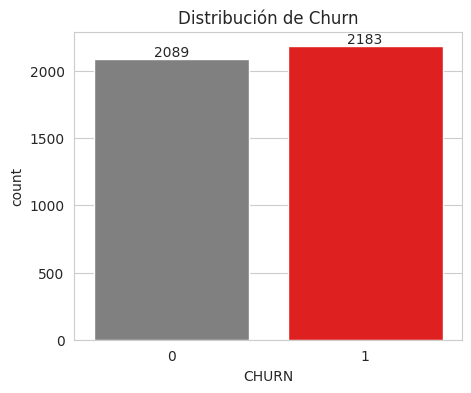

In [ ]:
# Distribución de churn

# Configuración visual
sns.set_style("whitegrid")

palette = {0: "gray", 1: "red"}

plt.figure(figsize=(5,4))

# Asignamos el gráfico a una variable 'ax' para acceder a sus ejes
ax = sns.countplot(x='CHURN', data=df, hue='CHURN', palette = palette, legend=False)

# Añadimos las etiquetas de datos sobre cada barra
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribución de Churn")
plt.savefig('grafico_churn.png', dpi=300)


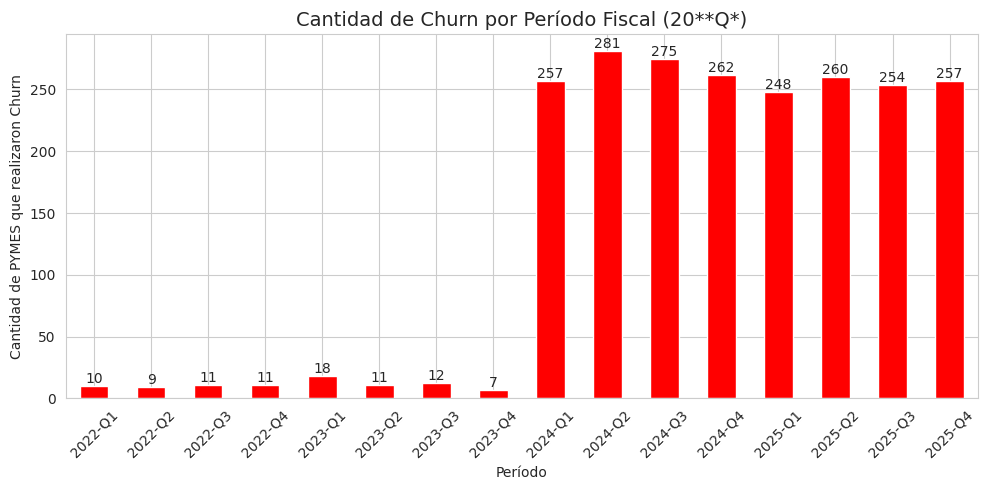

In [ ]:
# Trimestre con más Churn

# Configuración visual
sns.set_style("whitegrid")

# Filtrar churn
df_churn = df[df['CHURN'] == 1]

# Conteo de churn por período
churn_por_periodo = (
    df_churn['PERIODO_FISCAL']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))
ax = churn_por_periodo.plot(kind='bar', color='red')

# Etiquetas numéricas sobre las barras
for container in ax.containers:
    ax.bar_label(container)

plt.title("Cantidad de Churn por Período Fiscal (20**Q*)", fontsize=14)
plt.xlabel("Período")
plt.ylabel("Cantidad de PYMES que realizaron Churn")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


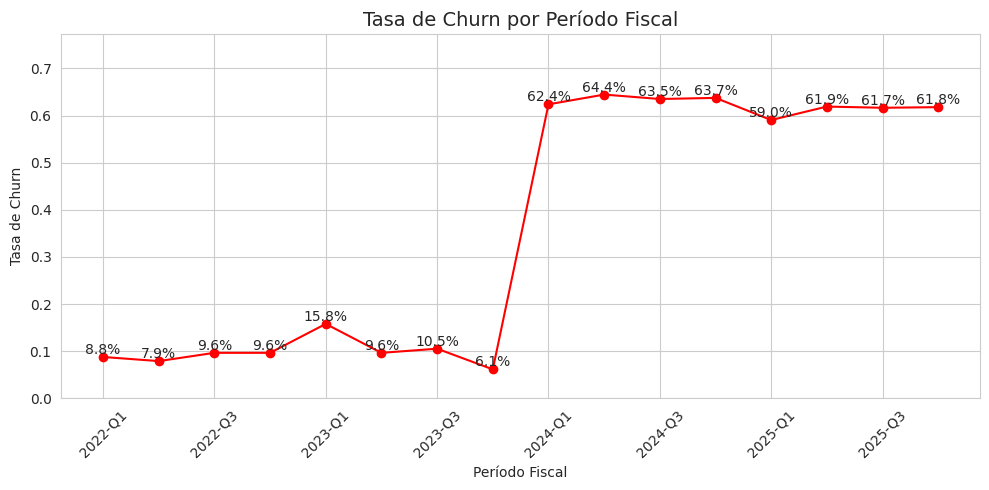

In [ ]:
# Tasa de Churn por Período

# Configuración visual
sns.set_style("whitegrid")

# Total de clientes por período
clientes_por_periodo = (
    df.groupby('PERIODO_FISCAL')
      .size()
)

# Clientes churn por período
churn_por_periodo = (
    df[df['CHURN'] == 1]
    .groupby('PERIODO_FISCAL')
    .size()
)

# Tasa de churn
tasa_churn = (churn_por_periodo / clientes_por_periodo).fillna(0)

# Ordenar por período
tasa_churn = tasa_churn.sort_index()

plt.figure(figsize=(10,5))
ax = tasa_churn.plot(marker='o', color= "red")

# Etiquetas de valor
for x, y in enumerate(tasa_churn):
    ax.text(
        x,
        y,
        f'{y:.1%}',
        ha='center',
        va='bottom'
    )

plt.title("Tasa de Churn por Período Fiscal", fontsize=14)
plt.xlabel("Período Fiscal")
plt.ylabel("Tasa de Churn")
plt.ylim(0, tasa_churn.max() * 1.2)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


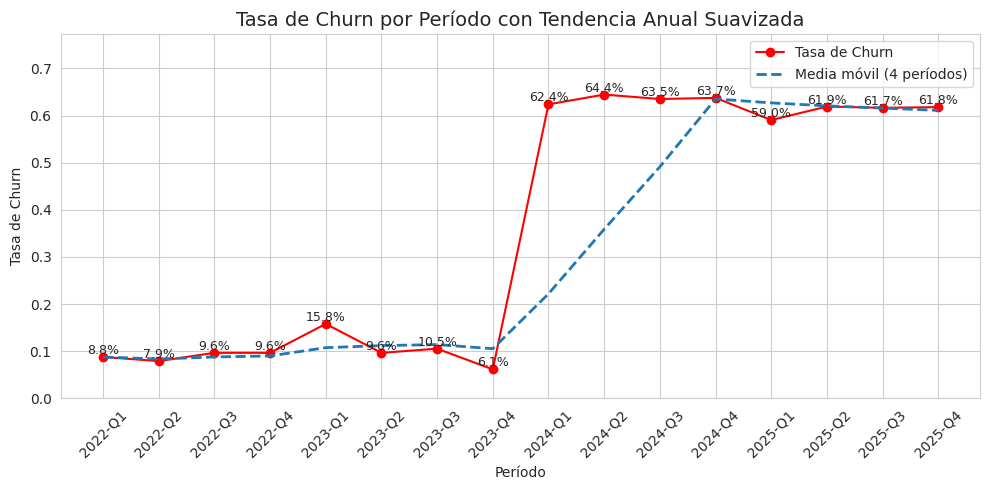

In [ ]:
# Tasa de Churn por Período Fiscal con Media Móvil

# Configuración visual
sns.set_style("whitegrid")

# Total de clientes por período
clientes_por_periodo = (
    df.groupby('PERIODO_FISCAL')
      .size()
)

# Clientes churn por período
churn_por_periodo = (
    df[df['CHURN'] == 1]
    .groupby('PERIODO_FISCAL')
    .size()
)

# Tasa de churn
tasa_churn = (churn_por_periodo / clientes_por_periodo).fillna(0)
tasa_churn = tasa_churn.sort_index()

# Media móvil de 4 períodos (≈ 1 año)
tasa_churn_mm = tasa_churn.rolling(window=4, min_periods=1).mean()

plt.figure(figsize=(10,5))

# Serie original
plt.plot(
    tasa_churn.index,
    tasa_churn.values,
    marker='o',
    label='Tasa de Churn',
    color='red'
)

# Tendencia suavizada
plt.plot(
    tasa_churn_mm.index,
    tasa_churn_mm.values,
    linestyle='--',
    linewidth=2,
    label='Media móvil (4 períodos)'
)

# Etiquetas de porcentaje
for x, y in enumerate(tasa_churn):
    plt.text(
        x,
        y,
        f'{y:.1%}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Tasa de Churn por Período con Tendencia Anual Suavizada", fontsize=14)
plt.xlabel("Período")
plt.ylabel("Tasa de Churn")
plt.ylim(0, max(tasa_churn.max(), tasa_churn_mm.max()) * 1.2)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


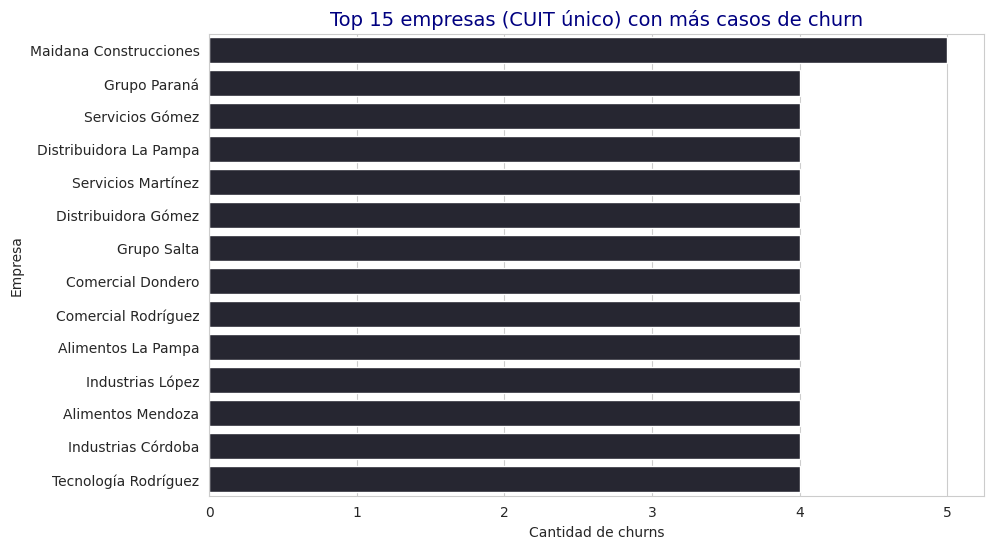

In [ ]:
# Top 15 empresas que más hicieron Churn
# Configuración visual
sns.set_style("whitegrid")
sns.set_palette("dark:blue")

# --- 1. Agrupar por CUIT y contar churn ---
df_churn_counts = (
    df[df['CHURN'] == 1]
    .groupby(['CUIT','NOMBRE_EMPRESA'])['CHURN']
    .count()
    .reset_index()
)
df_churn_counts = df_churn_counts.rename(columns={'CHURN': 'CHURN_COUNT'})

# --- 2. Seleccionar top 15 ---
top15_churn = df_churn_counts.nlargest(15, 'CHURN_COUNT')

# --- 3. Gráfico ---
plt.figure(figsize=(10,6))
sns.barplot(x='CHURN_COUNT', y='NOMBRE_EMPRESA', data=top15_churn)
plt.title("Top 15 empresas (CUIT único) con más casos de churn", fontsize=14, color='navy')
plt.xlabel("Cantidad de churns")
plt.ylabel("Empresa")
plt.show()



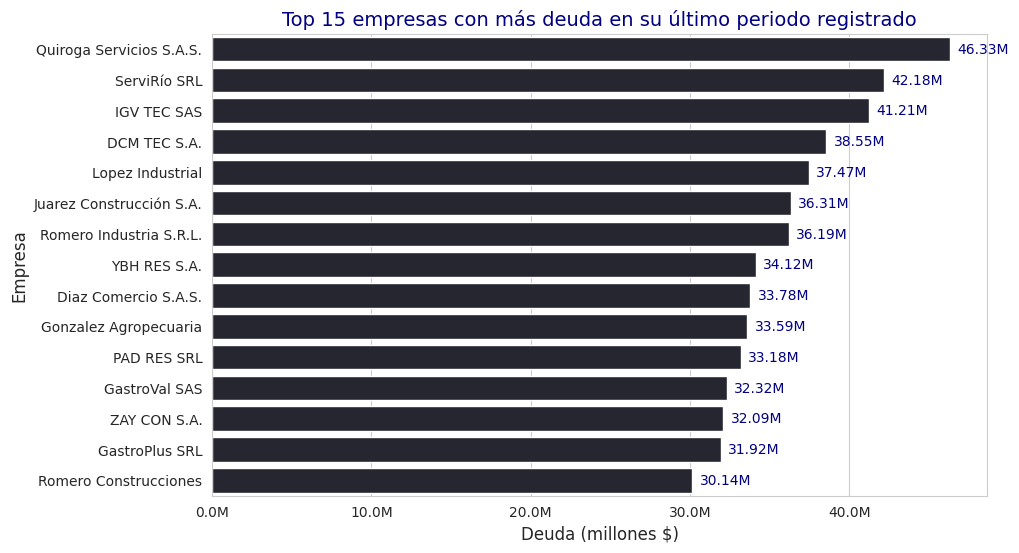

In [ ]:
# Top 15 empresas con mayor deuda registrada en su último período fiscal
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configuración visual
sns.set_style("whitegrid")
sns.set_palette("dark:blue")

# --- Selección del último periodo por CUIT ---
# Convertimos PERIODO_FISCAL a un orden temporal (ejemplo: YYYY-Q#)
df['PERIODO_ORDEN'] = pd.PeriodIndex(df['PERIODO_FISCAL'], freq='Q')

# Para cada CUIT, tomamos el registro más reciente
df_last = df.sort_values('PERIODO_ORDEN').groupby('CUIT').tail(1)

# --- Top 15 empresas con más deuda en su último periodo ---
top15_deuda_last = df_last.nlargest(15, 'DEUDA')

plt.figure(figsize=(10,6))
ax = sns.barplot(x='DEUDA', y='NOMBRE_EMPRESA', data=top15_deuda_last)

# Título y etiquetas
plt.title("Top 15 empresas con más deuda en su último periodo registrado", fontsize=14, color='navy')
plt.xlabel("Deuda (millones $)", fontsize=12)
plt.ylabel("Empresa", fontsize=12)

# Formatear eje X en millones
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Mostrar valores en cada barra
for p in ax.patches:
    width = p.get_width()
    plt.text(width + (0.01 * max(top15_deuda_last['DEUDA'])),   # posición X
             p.get_y() + p.get_height()/2,                      # posición Y
             f'{width/1e6:.2f}M',                               # texto en millones
             ha='left', va='center', fontsize=10, color='navy')

plt.show()



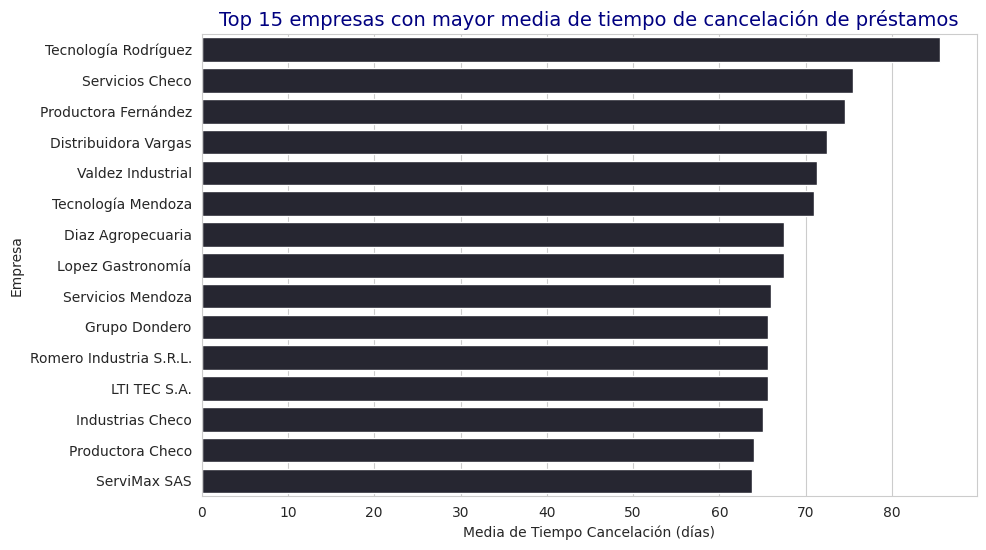

In [ ]:
# Top 15 empresas con mayor media de tiempo de cancelación de préstamos ---

# --- Agrupación por CUIT y NOMBRE_EMPRESA ---
df_grouped = df.groupby(['CUIT','NOMBRE_EMPRESA']).agg({
    'DEUDA':'mean',
    'TIEMPO_CANCELACION_PRESTAMO':'mean',
    'TOTAL_LOGIN_DIA':'mean',
    'MARGEN':'mean',
    'PRESTAMOS_APROBADOS':'mean'
}).reset_index()

# Configuración visual
sns.set_style("whitegrid")
sns.set_palette("dark:blue")

top15_cancelacion = df_grouped.nlargest(15, 'TIEMPO_CANCELACION_PRESTAMO')
plt.figure(figsize=(10,6))
sns.barplot(x='TIEMPO_CANCELACION_PRESTAMO', y='NOMBRE_EMPRESA', data=top15_cancelacion)
plt.title("Top 15 empresas con mayor media de tiempo de cancelación de préstamos", fontsize=14, color='navy')
plt.xlabel("Media de Tiempo Cancelación (días)")
plt.ylabel("Empresa")
plt.show()

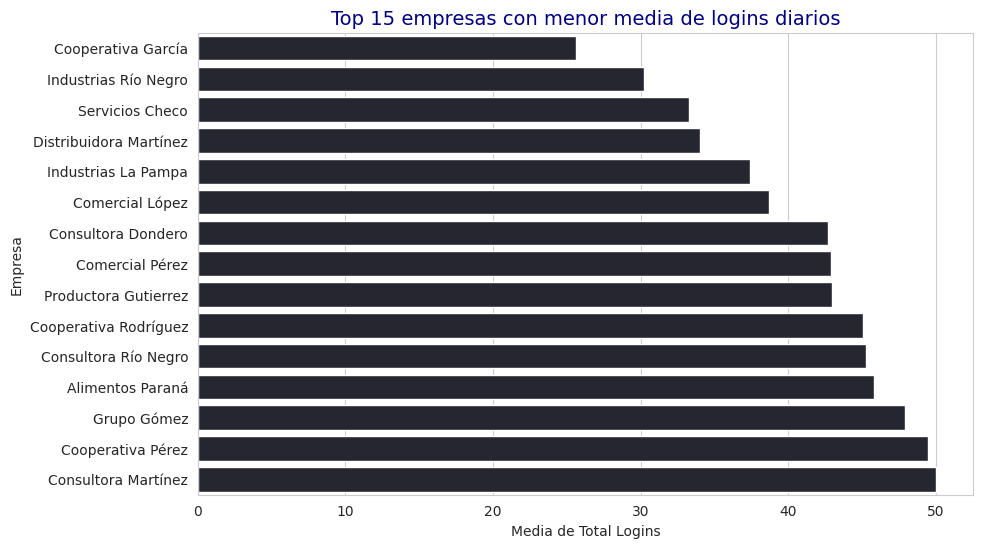

In [ ]:
# Top 15 empresas con menor media de total de logins ---

# --- Agrupación por CUIT y NOMBRE_EMPRESA ---
df_grouped = df.groupby(['CUIT','NOMBRE_EMPRESA']).agg({
    'DEUDA':'mean',
    'TIEMPO_CANCELACION_PRESTAMO':'mean',
    'TOTAL_LOGIN_DIA':'mean',
    'MARGEN':'mean',
    'PRESTAMOS_APROBADOS':'mean'
}).reset_index()

# Configuración visual
sns.set_style("whitegrid")
sns.set_palette("dark:blue")

top15_login = df_grouped.nsmallest(15, 'TOTAL_LOGIN_DIA')
plt.figure(figsize=(10,6))
sns.barplot(x='TOTAL_LOGIN_DIA', y='NOMBRE_EMPRESA', data=top15_login)
plt.title("Top 15 empresas con menor media de logins diarios", fontsize=14, color='navy')
plt.xlabel("Media de Total Logins")
plt.ylabel("Empresa")
plt.show()

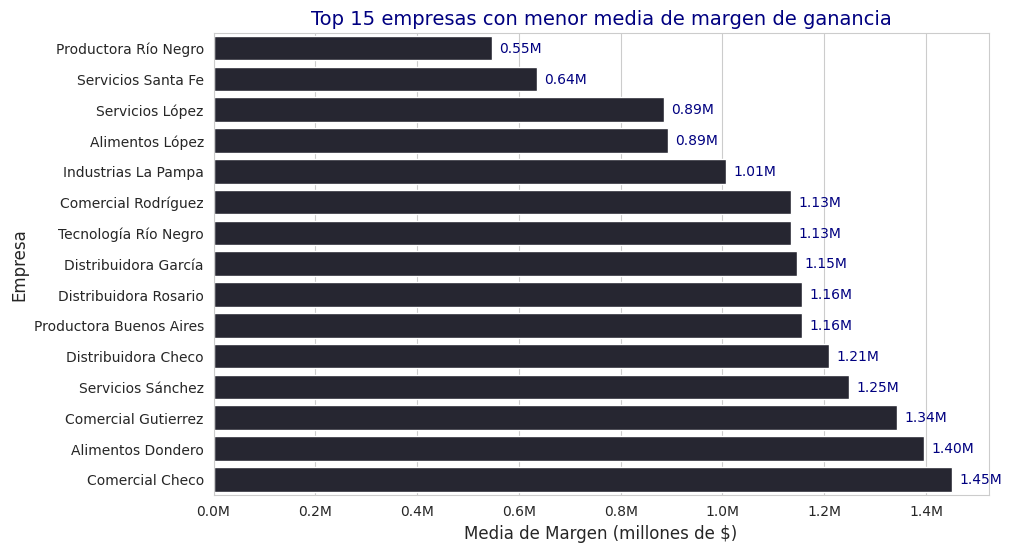

In [ ]:
# Top 15 empresas con menor margen de ganancia
from matplotlib.ticker import FuncFormatter

# Configuración visual
sns.set_style("whitegrid")
sns.set_palette("dark:blue")

# --- Selección de top 15 con menor margen ---
top15_margen = df_grouped.nsmallest(15, 'MARGEN')

plt.figure(figsize=(10,6))
ax = sns.barplot(x='MARGEN', y='NOMBRE_EMPRESA', data=top15_margen)

# Título y etiquetas
plt.title("Top 15 empresas con menor media de margen de ganancia", fontsize=14, color='navy')
plt.xlabel("Media de Margen (millones de $)", fontsize=12)
plt.ylabel("Empresa", fontsize=12)

# Formatear eje X en millones
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Mostrar valores en cada barra
for p in ax.patches:
    width = p.get_width()
    plt.text(width + (0.01 * max(top15_margen['MARGEN'])),  # posición X
             p.get_y() + p.get_height()/2,                  # posición Y
             f'{width/1e6:.2f}M',                           # texto en millones
             ha='left', va='center', fontsize=10, color='navy')

plt.show()


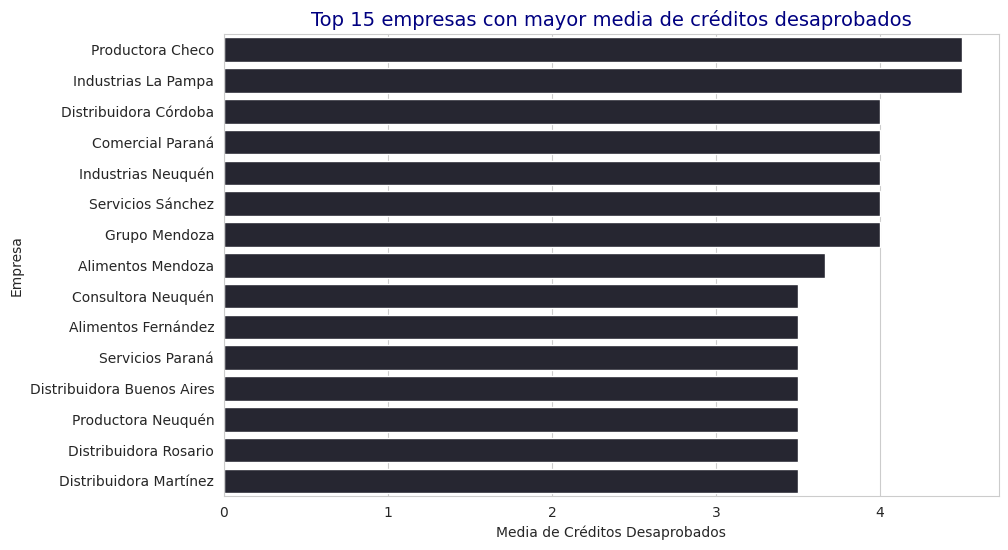

In [ ]:
# Top 15 empresas con mayor media de créditos desaprobados ---

# --- Crear columna de créditos desaprobados ---
df['CREDITOS_DESAPROBADOS'] = df['PRESTAMOS_SOLICITADOS'] - df['PRESTAMOS_APROBADOS']

# --- Agrupación por CUIT y NOMBRE_EMPRESA ---
df_grouped = df.groupby(['CUIT','NOMBRE_EMPRESA']).agg({
    'DEUDA':'mean',
    'TIEMPO_CANCELACION_PRESTAMO':'mean',
    'TOTAL_LOGIN_DIA':'mean',
    'MARGEN':'mean',
    'PRESTAMOS_APROBADOS':'mean',
    'CREDITOS_DESAPROBADOS':'mean'
}).reset_index()

# Configuración visual
sns.set_style("whitegrid")
sns.set_palette("dark:blue")


top15_desaprobados = df_grouped.nlargest(15, 'CREDITOS_DESAPROBADOS')

plt.figure(figsize=(10,6))
sns.barplot(x='CREDITOS_DESAPROBADOS', y='NOMBRE_EMPRESA', data=top15_desaprobados)
plt.title("Top 15 empresas con mayor media de créditos desaprobados", fontsize=14, color='navy')
plt.xlabel("Media de Créditos Desaprobados")
plt.ylabel("Empresa")
plt.show()



# **3. Ingeniería de Features**

La ingeniería de variables permite capturar patrones de comportamiento
financiero y de uso del producto.  
Se incluyen transformaciones temporales, agregaciones y variables derivadas
que mejoran la capacidad predictiva del modelo.


In [ ]:
# Carga de librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
from sklearn.base import BaseEstimator, TransformerMixin
import lightgbm as lgb
import joblib

In [ ]:
# --- 0) Utilidades ---
def periodo_to_timestamp(s):
    # "YYYY-Q#" -> primer día del trimestre
    return pd.PeriodIndex(s, freq='Q').to_timestamp()

def best_threshold_fintech(y_true, y_proba, beta=2):
    """
    Optimiza el umbral para Churn de PyMEs.
    beta > 1 prioritiza Recall (capturar fugas).
    beta = 1 es el F1-Score estándar.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    # Calculamos F-beta para darle más peso al Recall (evitar fugas de capital)
    beta_sq = beta**2
    f_scores = (1 + beta_sq) * (precision * recall) / ((beta_sq * precision) + recall + 1e-12)

    # Buscamos el índice del mejor score
    idx = np.nanargmax(f_scores)

    # Ajuste por la diferencia de longitud entre thresholds y precision/recall
    best_thr = thresholds[max(idx-1, 0)]

    return best_thr

In [ ]:
# --- 1) Feature builder ---
class PymerFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        # Ratios y derivados
        denom_days = (X['TRIMESTRE_DIAS_ACTIVIDAD'] + X['TRIMESTRE_DIAS_INACTIVIDAD']).replace(0, np.nan)
        X['RATIO_INACTIVIDAD'] = X['TRIMESTRE_DIAS_INACTIVIDAD'] / denom_days
        X['ENGAGEMENT_LOGIN'] = X['TOTAL_LOGIN_DIA'] / X['TRIMESTRE_DIAS_ACTIVIDAD'].replace(0, np.nan)
        X['MARGEN'] = X.get('MARGEN', X['INGRESOS'] - X['GASTOS'])
        X['MARGEN_RATIO'] = X['MARGEN'] / X['INGRESOS'].replace(0, np.nan)
        X['DEUDA_ACTIVOS_RATIO'] = X['DEUDA'] / X['ACTIVOS'].replace(0, np.nan)
        X['TASA_APROBACION_PRESTAMOS'] = X['PRESTAMOS_APROBADOS'] / X['PRESTAMOS_SOLICITADOS'].replace(0, np.nan)
        X['TASA_APROBACION_MONTO'] = X['MONTO_APROBADO'] / X['MONTO_SOLICITADO'].replace(0, np.nan)
        # Temporales
        X['ANIO'] = X['PERIODO_FISCAL'].str.split('-').str[0].astype(int)
        X['TRIMESTRE'] = X['PERIODO_FISCAL'].str.split('-').str[1]
        X['PERIODO_TS'] = periodo_to_timestamp(X['PERIODO_FISCAL'])
        # Servicios
        X['USO_SERVICIOS'] = X[['TRANSFERENCIAS','PAGOS','CREDITOS','INVERSIONES']].sum(axis=1)
        return X


# **4. Entrenamiento del modelo**

### Pre-proceso de los datos

In [ ]:
# --- 2) Columnas ---
cat_cols = ['TRIMESTRE']
num_cols = [
    'EMPLEADOS','INGRESOS','GASTOS','MARGEN','DEUDA','ACTIVOS',
    'PRESTAMOS_SOLICITADOS','PRESTAMOS_APROBADOS','MONTO_SOLICITADO','MONTO_APROBADO',
    'TICKET_PROMEDIO_SOLICITADO','TICKET_PROMEDIO_APROBADO',
    'PRESTAMOS_CANCELADOS','PRESTAMOS_VIGENTES','TIEMPO_CANCELACION_PRESTAMO',
    'SERVICIOS_UTILIZADOS','TRANSFERENCIAS','PAGOS','CREDITOS','INVERSIONES',
    'TRIMESTRE_DIAS_ACTIVIDAD','TRIMESTRE_DIAS_INACTIVIDAD','PROMEDIO_LOGIN_DIA','TOTAL_LOGIN_DIA',
    'ANIO','USO_SERVICIOS',
    'RATIO_INACTIVIDAD','ENGAGEMENT_LOGIN','MARGEN_RATIO','DEUDA_ACTIVOS_RATIO',
    'TASA_APROBACION_PRESTAMOS','TASA_APROBACION_MONTO'
]

preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

In [ ]:
# --- 4) Datos base ---
X_full = df.drop(columns=['CHURN','NOMBRE_EMPRESA', 'CUIT'])
y_full = df['CHURN'].astype(int)
cuits = df['CUIT']  # para agrupar por empresa

### Set de parametros de LightGBM + Pipeline

In [ ]:
# --- 3) Modelo ---
lgb_model = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    is_unbalance=True

)



In [ ]:
pipeline = Pipeline(steps=[
    ('feat', PymerFeatureBuilder()),
    ('prep', preprocess),
    ('model', lgb_model)
])


### Segmentación de los datos por períodos de tiempo para el entrenamiento

In [ ]:
# --- 5) Folds temporales con rolling origin + bloqueo por CUIT ---
# Ordenar por PERIODO_TS
order = pd.Series(periodo_to_timestamp(df['PERIODO_FISCAL'])).sort_values().index
X_ord = X_full.iloc[order]
y_ord = y_full.iloc[order]
cuits_ord = cuits.iloc[order]

# Definir cortes temporales (ejemplo: 5 folds)
# Cada fold valida en un bloque futuro y entrena con todo lo anterior
unique_periods = pd.PeriodIndex(df.loc[order, 'PERIODO_FISCAL'], freq='Q')
period_list = pd.Series(unique_periods).unique()
n_folds = min(5, len(period_list)-1)

folds = []
for k in range(1, n_folds+1):
    # Usamos los primeros k periodos para train y el siguiente para test
    train_periods = period_list[:k]
    test_period = period_list[k]
    train_idx = X_ord.index[unique_periods.isin(train_periods)]
    test_idx = X_ord.index[unique_periods == test_period]
    folds.append((train_idx, test_idx))

### Pre-entrenamiento con validación, umbrales y agrupación de 'CUIT' en los sets

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np
from lightgbm.callback import early_stopping, log_evaluation # Import callbacks

# --- 6) CV con GroupKFold, early stopping y umbral óptimo por fold ---

auc_scores, f1_scores, thresholds_used = [], [], []

# GroupKFold usando CUIT como grupo
gkf = GroupKFold(n_splits=5)
folds = gkf.split(X_ord, y_ord, groups=cuits_ord)

for fold_num, (train_idx, test_idx) in enumerate(folds):
    print(f"Processing Fold {fold_num + 1}/5")

    # Split de datos (sin bloqueo manual)
    X_tr_raw, X_te_raw = X_ord.loc[train_idx], X_ord.loc[test_idx]
    y_tr_raw, y_te_raw = y_ord.loc[train_idx], y_ord.loc[test_idx]

    # Crear sub-pipeline SOLO para preparar eval_set
    prep_for_eval = Pipeline(steps=[
        ('feat', PymerFeatureBuilder()),
        ('prep', ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), num_cols),
                ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
            ],
            remainder='drop'
        ))
    ])

    # Transformar datos para eval_set
    X_tr_transformed_for_eval = prep_for_eval.fit_transform(X_tr_raw, y_tr_raw)
    X_te_transformed_for_eval = prep_for_eval.transform(X_te_raw)

    # Entrenamiento con early stopping
    pipeline.set_params(model__n_estimators=1000)
    pipeline.fit(
        X_tr_raw, y_tr_raw,
        model__eval_set=[
            (X_tr_transformed_for_eval, y_tr_raw),
            (X_te_transformed_for_eval, y_te_raw)
        ],
        model__eval_metric='auc',
        model__callbacks=[early_stopping(100, verbose=False)] # Use callbacks instead of early_stopping_rounds
    )

    # Predicciones y umbral óptimo por fold
    y_proba = pipeline.predict_proba(X_te_raw)[:, 1]
    thr = best_threshold_fintech(y_te_raw, y_proba) # Removed 'method="f1"'
    y_pred = (y_proba >= thr).astype(int)

    auc_scores.append(roc_auc_score(y_te_raw, y_proba))
    f1_scores.append(f1_score(y_te_raw, y_pred))
    thresholds_used.append(thr)

# Resultados finales
print("ROC-AUC (folds):", np.round(auc_scores, 4), "Promedio:", np.mean(auc_scores))
print("F1 (folds):", np.round(f1_scores, 4), "Promedio:", np.mean(f1_scores))
print("Umbrales usados por fold:", np.round(thresholds_used, 3))

Processing Fold 1/5
[LightGBM] [Info] Number of positive: 1765, number of negative: 1651
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002640 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4588
[LightGBM] [Info] Number of data points in the train set: 3416, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516686 -> initscore=0.066770
[LightGBM] [Info] Start training from score 0.066770


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Processing Fold 2/5
[LightGBM] [Info] Number of positive: 1760, number of negative: 1658
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4593
[LightGBM] [Info] Number of data points in the train set: 3418, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514921 -> initscore=0.059702
[LightGBM] [Info] Start training from score 0.059702


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Processing Fold 3/5
[LightGBM] [Info] Number of positive: 1719, number of negative: 1699
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4598
[LightGBM] [Info] Number of data points in the train set: 3418, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502926 -> initscore=0.011703
[LightGBM] [Info] Start training from score 0.011703


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Processing Fold 4/5
[LightGBM] [Info] Number of positive: 1751, number of negative: 1667
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002389 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4594
[LightGBM] [Info] Number of data points in the train set: 3418, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512288 -> initscore=0.049161
[LightGBM] [Info] Start training from score 0.049161


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Processing Fold 5/5
[LightGBM] [Info] Number of positive: 1737, number of negative: 1681
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4587
[LightGBM] [Info] Number of data points in the train set: 3418, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508192 -> initscore=0.032771
[LightGBM] [Info] Start training from score 0.032771
ROC-AUC (folds): [0.9368 0.9235 0.9387 0.9285 0.9294] Promedio: 0.9313863570133503
F1 (folds): [0.8711 0.8378 0.8821 0.8703 0.8672] Promedio: 0.8656775334445508
Umbrales usados por fold: [0.297 0.454 0.496 0.317 0.322]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Entrenamiento final del modelo LightGBM + exportación

In [ ]:
# Entrenamiento final y exportación ---
# Entrenar con todo el histórico usando el mejor número de árboles encontrado en early stopping del último fold
best_n_estimators = 1200 # Default value
if auc_scores: # Only if at least one fold was processed
    if hasattr(pipeline.named_steps['model'], 'best_iteration_') and pipeline.named_steps['model'].best_iteration_ is not None:
        best_n_estimators = pipeline.named_steps['model'].best_iteration_
    else:
        print("Warning: best_iteration_ not found, using default n_estimators for final model.")

pipeline.set_params(model__n_estimators=best_n_estimators)
pipeline.fit(X_ord, y_ord) # Fit the final model on the full ordered dataset

# Guardar pipeline y umbral promedio (para la API)
final_threshold = float(np.mean(thresholds_used)) if thresholds_used else 0.5 # Default to 0.5 if no folds processed
artifact = {"pipeline": pipeline, "threshold": final_threshold}
joblib.dump(artifact, "pymer_churn_pipeline.pkl")
print(f"Exportado pymer_churn_pipeline.pkl con umbral promedio {final_threshold:.3f}")

[LightGBM] [Info] Number of positive: 2183, number of negative: 2089
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000794 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4583
[LightGBM] [Info] Number of data points in the train set: 4272, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.511002 -> initscore=0.044015
[LightGBM] [Info] Start training from score 0.044015
Exportado pymer_churn_pipeline.pkl con umbral promedio 0.377



# **5. Evaluación del Modelo**

Se evalúa el desempeño del modelo utilizando múltiples métricas,
poniendo especial foco en *Recall* y *F1-score*, métricas clave
para la detección temprana de churn.


In [ ]:
from sklearn.metrics import (
    recall_score, f1_score, precision_score, roc_auc_score
)

# Probabilidades del modelo final
y_proba_final = pipeline.predict_proba(X_ord)[:, 1]

# Predicción binaria usando el umbral promedio exportado
y_pred_final = (y_proba_final >= final_threshold).astype(int)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
recall = recall_score(y_ord, y_pred_final)
f1 = f1_score(y_ord, y_pred_final)
precision = precision_score(y_ord, y_pred_final)
auc = roc_auc_score(y_ord, y_proba_final)

metrics = {
    "Recall": recall,
    "F1-score": f1,
    "Precision": precision,
    "ROC-AUC": auc
}

metrics


{'Recall': 0.9303710490151168,
 'F1-score': 0.8865124399825404,
 'Precision': 0.846602751146311,
 'ROC-AUC': np.float64(0.9820785402322266)}

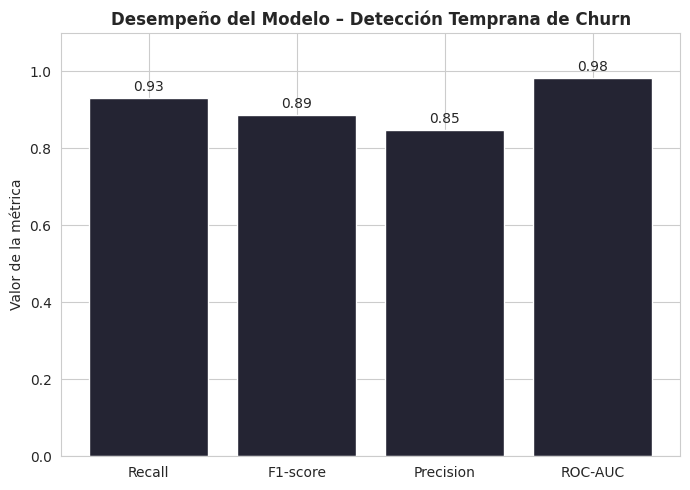

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
# Guardamos la referencia de las barras en una variable
bars = plt.bar(metrics.keys(), metrics.values())

# Agregamos las etiquetas de datos sobre cada barra
plt.bar_label(bars, padding=3, fmt='%.2f')

plt.ylim(0, 1.1) # Subimos un poco el límite para que el texto no se corte
plt.title("Desempeño del Modelo – Detección Temprana de Churn", fontweight='bold')
plt.ylabel("Valor de la métrica")
plt.tight_layout()
plt.show()


## Matríz de confución

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Figure size 500x500 with 0 Axes>

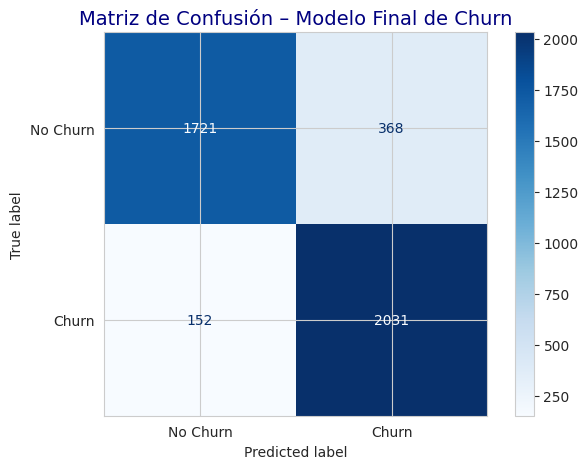

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Predicciones del modelo final ---
y_proba_final = pipeline.predict_proba(X_ord)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

# --- Matriz de confusión ---
cm = confusion_matrix(y_ord, y_pred_final)

# --- Visualización ---
plt.figure(figsize=(5,5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot(cmap="Blues", values_format='d')

plt.title(
    "Matriz de Confusión – Modelo Final de Churn",
    fontsize=14,
    color='navy'
)
plt.tight_layout()
plt.show()


## Impacto de la predicción del modelo en el negocio

In [ ]:
# Supuestos de negocio (AJUSTABLES)
COSTO_ACCION = 10        # costo por cliente contactado ($)
BENEFICIO_SALVADO = 120  # beneficio esperado por cliente retenido ($)


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_ord, y_pred_final)

tn, fp, fn, tp = cm.ravel()

confusion_df = pd.DataFrame(
    cm,
    index=["No Churn Real", "Churn Real"],
    columns=["No Churn Predicho", "Churn Predicho"]
)

confusion_df


,No Churn Predicho,Churn Predicho
No Churn Real,1721,368
Churn Real,152,2031


In [ ]:
impacto_df = pd.DataFrame({
    "Métrica": [
        "Clientes detectados a tiempo (TP)",
        "Clientes contactados innecesariamente (FP)",
        "Clientes que churnearon sin detectar (FN)",
        "Clientes correctamente ignorados (TN)"
    ],
    "Cantidad": [tp, fp, fn, tn],
    "Impacto económico ($)": [
        tp * BENEFICIO_SALVADO,
        -fp * COSTO_ACCION,
        -fn * BENEFICIO_SALVADO,
        0
    ]
})

impacto_df


,Métrica,Cantidad,Impacto económico ($)
0,Clientes detectados a tiempo (TP),2031,243720
1,Clientes contactados innecesariamente (FP),368,-3680
2,Clientes que churnearon sin detectar (FN),152,-18240
3,Clientes correctamente ignorados (TN),1721,0


In [ ]:
impacto_total = impacto_df["Impacto económico ($)"].sum()

impacto_total


np.int64(221800)

In [ ]:
tabla_negocio = pd.DataFrame({
    "Indicador": [
        "Clientes contactados",
        "Clientes salvados",
        "Costo total acciones ($)",
        "Beneficio por retención ($)",
        "Impacto neto del modelo ($)"
    ],
    "Valor": [
        tp + fp,
        tp,
        fp * COSTO_ACCION,
        tp * BENEFICIO_SALVADO,
        impacto_total
    ]
})

tabla_negocio


,Indicador,Valor
0,Clientes contactados,2399
1,Clientes salvados,2031
2,Costo total acciones ($),3680
3,Beneficio por retención ($),243720
4,Impacto neto del modelo ($),221800


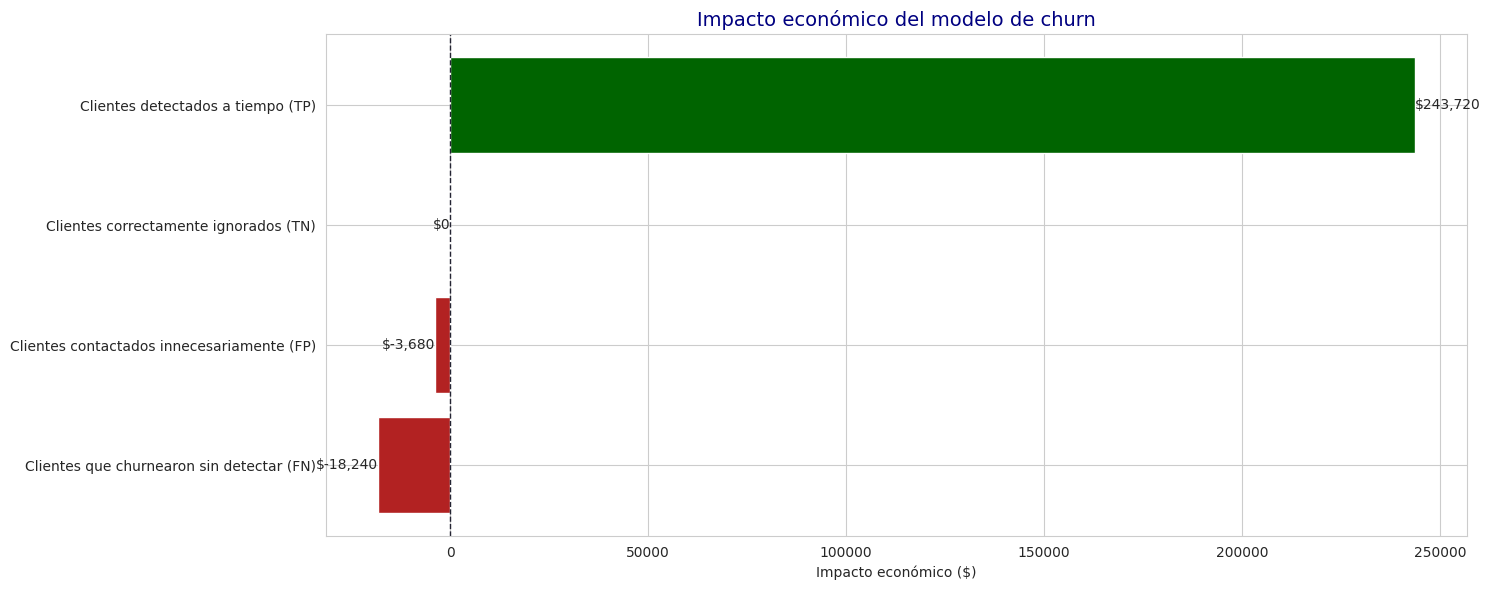

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenar por impacto
impacto_df = impacto_df.sort_values("Impacto económico ($)")

# Colores: verde = beneficio, rojo = costo
colors = impacto_df["Impacto económico ($)"].apply(
    lambda x: "darkgreen" if x >= 0 else "firebrick"
)

plt.figure(figsize=(15,6))
bars = plt.barh(
    impacto_df["Métrica"],
    impacto_df["Impacto económico ($)"],
    color=colors
)

# Línea vertical en cero (break-even)
plt.axvline(0, linestyle="--", linewidth=1)

# Etiquetas numéricas
for bar in bars:
    value = bar.get_width()
    plt.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f"${value:,.0f}",
        va="center",
        ha="left" if value > 0 else "right",
        fontsize=10
    )

plt.title(
    "Impacto económico del modelo de churn",
    fontsize=14,
    color="navy"
)
plt.xlabel("Impacto económico ($)")
plt.ylabel("")

plt.tight_layout()
plt.show()



# **6. Conclusión**

“El modelo permite detectar anticipadamente a la mayoría de los clientes con riesgo de churn, generando un impacto económico neto positivo al priorizar acciones de retención donde más valor aportan.”

# **7. Test del modelo**

In [ ]:
#### TEST

In [ ]:
import pandas as pd
import joblib

# --- 1) Cargar el pipeline entrenado ---
artifact = joblib.load("pymer_churn_pipeline.pkl")
pipeline = artifact["pipeline"]
threshold = artifact["threshold"]

# --- 2) Crear un ejemplo de empresa ---
# Ajusta los valores según quieras simular distintos escenarios
empresa_ejemplo = {
    "CUIT": "20740000001",
    "NOMBRE_EMPRESA": "Dondero Tech",
    "PERIODO_FISCAL": "2025-Q4",
    "EMPLEADOS": 20,
    "INGRESOS": 1000000,
    "GASTOS": 900000,
    "DEUDA": 2000000,
    "ACTIVOS": 5000000,
    "PRESTAMOS_SOLICITADOS": 2,
    "PRESTAMOS_APROBADOS": 1,
    "MONTO_SOLICITADO": 1000000,
    "MONTO_APROBADO": 500000,
    "TICKET_PROMEDIO_SOLICITADO": 500000,
    "TICKET_PROMEDIO_APROBADO": 500000,
    "PRESTAMOS_CANCELADOS": 1,
    "PRESTAMOS_VIGENTES": 0,
    "TIEMPO_CANCELACION_PRESTAMO": 90,
    "SERVICIOS_UTILIZADOS": 2,
    "TRANSFERENCIAS": 1,
    "PAGOS": 0,
    "CREDITOS": 1,
    "INVERSIONES": 0,
    "TRIMESTRE_DIAS_ACTIVIDAD": 90,
    "TRIMESTRE_DIAS_INACTIVIDAD": 0,
    "PROMEDIO_LOGIN_DIA": 4,
    "TOTAL_LOGIN_DIA": 280
}

# Convertir a DataFrame
df_input = pd.DataFrame([empresa_ejemplo])

# --- 3) Realizar predicción ---
proba = pipeline.predict_proba(df_input)[:, 1][0]
pred = int(proba >= threshold)

print("Probabilidad de churn:", round(proba, 4))
print("Predicción binaria (0=Activo, 1=Churn):", pred)
print("Umbral usado:", round(threshold, 3))


Probabilidad de churn: 0.4675
Predicción binaria (0=Activo, 1=Churn): 1
Umbral usado: 0.377


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
